# Andmete eksploratiivne analüüs

In [ ]:
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

In [277]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style = 'whitegrid', font_scale= 1.1, rc = custom_params)

## Andmete import

In [163]:
# Impordi andmed puhastamise käigus loodud CVS-st
data = pd.read_csv('data/cleaned_data.csv')
data

,Vastaja_ID,K1_aeg,K2_kontroll,K3_vanus,K4_sugu,K5_elukoht,K6_keel,K7_sorteerimiskaitumine,K8_teadmiste_hinnang,K9_probleemi_tosidus,...,K32_teabe_allikad_10,K32_teabe_allikad_muu_tekst,K33_julgustavad_tegurid_1,K33_julgustavad_tegurid_2,K33_julgustavad_tegurid_3,K33_julgustavad_tegurid_4,K33_julgustavad_tegurid_5,K33_julgustavad_tegurid_6,K33_julgustavad_tegurid_7,K33_julgustavad_tegurid_muu_tekst
0,1,2025-03-10 08:01:13,1,2,2,1,1,2,5,5,...,0,NaN,1,1,1,1,0,1,0,NaN
1,2,2025-03-10 16:55:18,1,2,2,9,1,3,3,3,...,0,NaN,1,1,0,0,0,0,0,NaN
2,3,2025-03-17 21:06:37,1,4,2,1,1,2,4,5,...,0,NaN,1,1,0,1,0,0,0,NaN
3,4,2025-03-17 20:00:21,1,4,2,16,1,3,2,5,...,0,NaN,1,0,0,0,0,0,0,NaN
4,5,2025-03-20 21:15:13,1,2,2,12,1,3,4,5,...,0,NaN,1,1,1,1,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,674,2025-03-28 16:34:49,1,4,2,9,1,2,2,5,...,0,NaN,1,1,0,0,1,0,0,NaN
664,675,2025-04-13 09:46:43,1,2,2,1,1,4,4,5,...,0,NaN,1,1,1,0,0,0,0,NaN
665,676,2025-04-15 13:31:30,1,4,2,1,1,3,3,5,...,0,NaN,1,1,1,0,1,0,0,NaN
666,677,2025-03-11 19:48:03,1,3,2,1,1,3,3,4,...,0,NaN,1,0,1,0,0,0,0,NaN


In [221]:
koodid = pd.read_csv('data/vastuste_koodid.csv')
koodid

,kysimus,kood,vastus
0,K2_kontroll,1,Jah
1,K2_kontroll,2,Ei
2,K3_vanus,1,Alaealine (17 või noorem)
3,K3_vanus,2,18-29
4,K3_vanus,3,30-49
...,...,...,...
168,K43_roivaste_tellimine_proovimiseks,1,Ei ole seda kordagi teinud
169,K43_roivaste_tellimine_proovimiseks,2,2 - puudu
170,K43_roivaste_tellimine_proovimiseks,3,3 - puudu
171,K43_roivaste_tellimine_proovimiseks,4,4 - puudu


## Demograafilised näitajad

- Vanus
- Sugu
- Elukoht
- Keel

### Abifunktsioonid

In [416]:
def leia_sildi_mapping(df_labels, tunnus):
     return (
        df_labels[df_labels['kysimus'] == tunnus]
        .set_index('kood')['vastus']
        .to_dict()
    )

In [371]:
# Leia tunnuse väärtuste esinemise sagedused ja esita need tabelina
def sagedustabel_v2(df, veerg):
    jaotus = duckdb.sql(f'''
    SELECT
        t1.{veerg} as kood
        ,t2.vastus as vastus
    FROM df t1
    LEFT JOIN koodid t2 on t1.{veerg} = t2.kood
        AND t2.kysimus = '{veerg}'
    ORDER BY t1.K3_vanus
    ''').df()

    arv = jaotus['vastus'].value_counts(dropna=False)
    protsent = jaotus['vastus'].value_counts(normalize=True) * 100

    return pd.DataFrame({
        'vastuste_arv': arv,
        'protsent': protsent
    })

In [382]:
# Leia tunnuse väärtuste esinemise sagedused ja esita need tabelina
def sagedustabel(df_data, df_koodid, tunnus):
    
    # --- filter mapping for this question ---
    df_map = df_koodid[df_koodid['kysimus'] == tunnus].copy()
    df_map = df_map.sort_values('kood')  # ensures correct order
    
    # --- counts from data ---
    counts = df_data[tunnus].value_counts()
    
    # --- map counts onto full list of possible answers ---
    df_map["vastuste_arv"] = df_map["kood"].map(counts).fillna(0).astype(int)
    
    # --- percentages ---
    total = df_map["vastuste_arv"].sum()
    df_map["protsent"] = (df_map["vastuste_arv"] / total * 100).round(1)
    
    # --- final table ---
    tulemus = df_map[["vastus", "vastuste_arv", "protsent"]]

    return tulemus

In [242]:
# Leia tunnuse mood ehk kõige sagedamini esinev väärtus
def mood(df, veerg):
    jaotus = duckdb.sql(f'''
        SELECT
            t1.{veerg} as kood
            ,t2.vastus as vastus
        FROM df t1
        LEFT JOIN koodid t2 on t1.{veerg} = t2.kood
            AND t2.kysimus = '{veerg}'
        ORDER BY t1.K3_vanus
        ''').df()
    return jaotus.mode()

In [384]:
# Leia vastajate arv vanusegrupiti
vanuse_sagedus = sagedustabel(data, koodid, 'K3_vanus')
print('Vastanute vanuste jaotus:')
print(vanuse_sagedus.to_string(index=False))

Vastanute vanuste jaotus:
                   vastus  vastuste_arv  protsent
Alaealine (17 või noorem)            57       8.5
                    18-29           124      18.6
                    30-49           370      55.4
                    50-64           104      15.6
             65 või vanem            13       1.9


In [374]:
# Leia, millise grupi vastajaid on kõige rohkem
print('Kõige sagedasem vanusegrupp (mood):')
print(mood(data, 'K3_vanus'))

Kõige sagedasem vanusegrupp (mood):
   kood vastus
0     3  30-49


[Text(0, 0.5, '')]

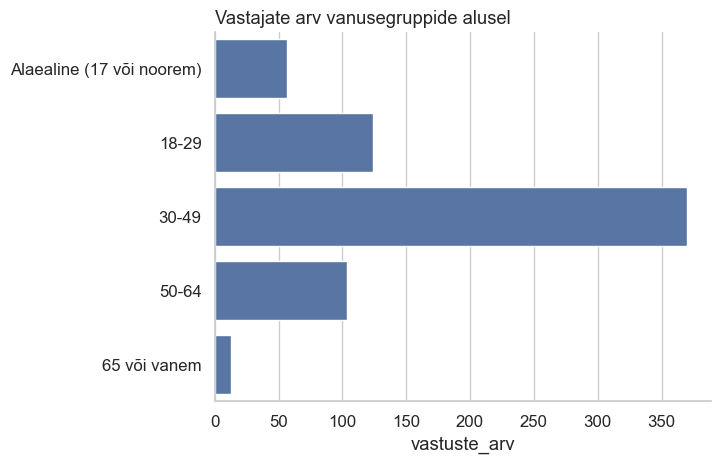

In [385]:
# fig = plt.figure(figsize=(4,4))
# fig.suptitle('Vastanute arv vanuse järgi')
# ax = fig.add_subplot()
ax = sns.barplot(vanuse_sagedus, y='vastus', x='vastuste_arv')
ax.set_title('Vastajate arv vanusegruppide alusel', loc='left')
ax.set(ylabel=None)
# ax.set(yticklabels=[])

In [411]:
# Leia vastajate arv soo alusel
sugu_sagedus = sagedustabel(data, koodid, 'K4_sugu').sort_values(['vastuste_arv'], ascending=False)
print('Vastanute vanuste jaotus:')
print(sugu_sagedus.to_string(index=False))

Vastanute vanuste jaotus:
             vastus  vastuste_arv  protsent
              Naine           591      88.5
               Mees            71      10.6
Ei soovi määratleda             6       0.9


In [264]:
# Leia, millise grupi vastajaid on kõige rohkem
print('Kõige sagedasem vanusegrupp (mood):')
print(mood(data, 'K4_sugu'))

Kõige sagedasem vanusegrupp (mood):
   kood vastus
0     2  Naine


[Text(0, 0.5, '')]

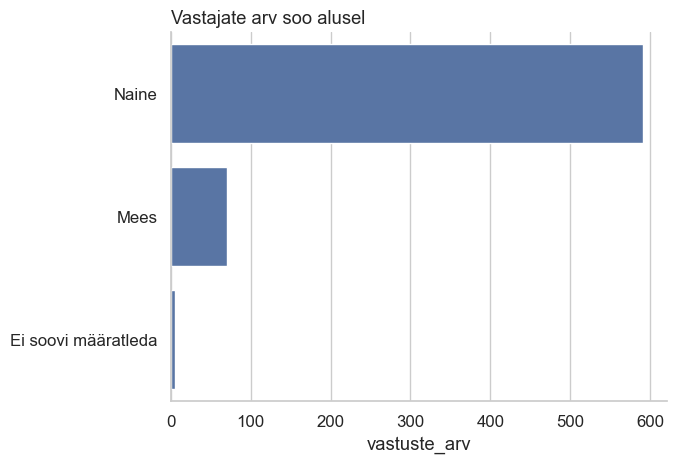

In [412]:
ax = sns.barplot(sugu_sagedus, y='vastus', x='vastuste_arv')
ax.set_title('Vastajate arv soo alusel', loc='left')
ax.set(ylabel=None)

In [394]:
# Leia vastajate arv elukoha alusel
elukoht_sagedus = sagedustabel(data, koodid, 'K5_elukoht').sort_values(['vastuste_arv'], ascending=False)
print('Vastanute vanuste jaotus:')
print(elukoht_sagedus.to_string(index=False))

Vastanute vanuste jaotus:
            vastus  vastuste_arv  protsent
     Harju maakond           406      60.8
     Tartu maakond            88      13.2
     Pärnu maakond            56       8.4
     Järva maakond            35       5.2
  Viljandi maakond            23       3.4
     Rapla maakond            13       1.9
Lääne-Viru maakond            12       1.8
    Jõgeva maakond             7       1.0
     Põlva maakond             6       0.9
     Saare maakond             5       0.7
      Võru maakond             4       0.6
               Muu             4       0.6
  Ida-Viru maakond             3       0.4
     Valga maakond             3       0.4
      Hiiu maakond             2       0.3
     Lääne maakond             1       0.1


In [378]:
# Leia, millise grupi vastajaid on kõige rohkem
print('Kõige sagedasem vanusegrupp (mood):')
print(mood(data, 'K5_elukoht'))

Kõige sagedasem vanusegrupp (mood):
   kood         vastus
0     1  Harju maakond


[Text(0, 0.5, '')]

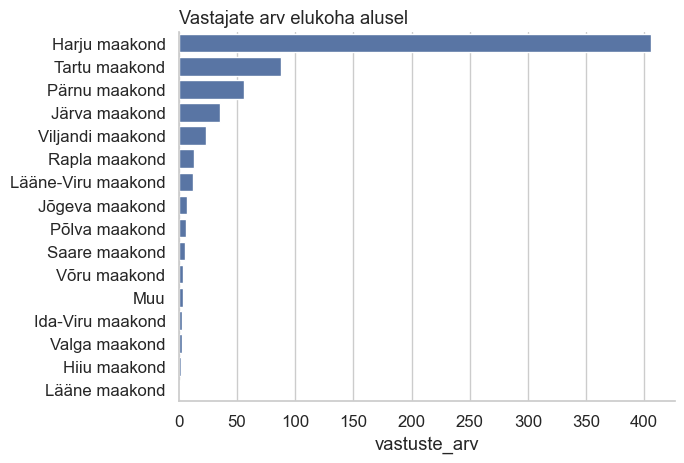

In [395]:
ax = sns.barplot(elukoht_sagedus, y='vastus', x='vastuste_arv')
ax.set_title('Vastajate arv elukoha alusel', loc='left')
ax.set(ylabel=None)

In [413]:
# Leia vastajate arv keele alusel
keel_sagedus = sagedustabel(data, koodid, 'K6_keel').sort_values(['vastuste_arv'], ascending=False)
print('Vastanute vanuste jaotus:')
print(keel_sagedus.to_string(index=False))

Vastanute vanuste jaotus:
      vastus  vastuste_arv  protsent
  Eesti keel           641      96.0
   Vene keel            15       2.2
Inglise keel             7       1.0
         Muu             5       0.7


In [171]:
# Leia, millise grupi vastajaid on kõige rohkem
print('Kõige sagedasem vanusegrupp (mood):')
print(mood(data, 'K6_keel'))

Kõige sagedasem vanusegrupp (mood):
   kood      vastus
0     1  Eesti keel


[Text(0, 0.5, '')]

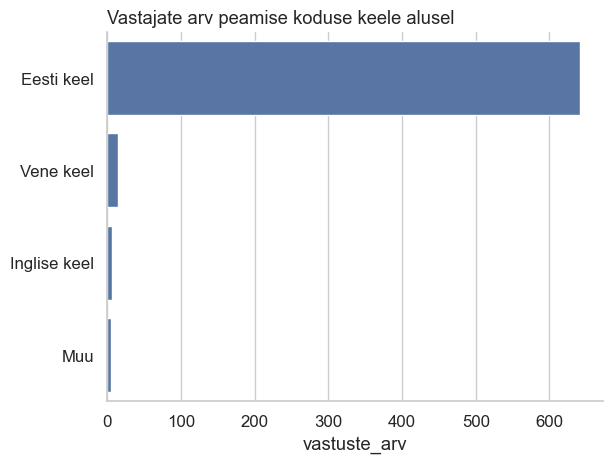

In [414]:
ax = sns.barplot(keel_sagedus, y='vastus', x='vastuste_arv')
ax.set_title('Vastajate arv peamise koduse keele alusel', loc='left')
ax.set(ylabel=None)

In [417]:
vanus_sildid = leia_sildi_mapping(koodid, 'K3_vanus')
sugu_sildid = leia_sildi_mapping(koodid, 'K4_sugu')

vanus_sugu = pd.crosstab(index=data['K3_vanus'], columns=data['K4_sugu'])

vanus_sugu.columns = sugu_sildid.values()
vanus_sugu.index = vanus_sildid.values()

vanus_sugu

,Mees,Naine,Ei soovi määratleda
Alaealine (17 või noorem),23,32,2
18-29,18,103,3
30-49,27,342,1
50-64,3,101,0
65 või vanem,0,13,0


In [418]:
vanus_sildid = leia_sildi_mapping(koodid, 'K3_vanus')
elukoht_sildid = leia_sildi_mapping(koodid, 'K5_elukoht')

vanus_elukoht = pd.crosstab(index=data['K5_elukoht'], columns=data['K3_vanus'])

vanus_elukoht.columns = vanus_sildid.values()
vanus_elukoht.index = elukoht_sildid.values()

vanus_elukoht

,Alaealine (17 või noorem),18-29,30-49,50-64,65 või vanem
Harju maakond,22,81,236,56,11
Hiiu maakond,0,0,2,0,0
Ida-Viru maakond,0,1,1,1,0
Järva maakond,26,5,2,2,0
Jõgeva maakond,1,1,2,3,0
Lääne maakond,0,0,0,1,0
Lääne-Viru maakond,2,5,5,0,0
Põlva maakond,0,0,4,1,1
Pärnu maakond,0,8,36,12,0
Rapla maakond,0,1,6,6,0


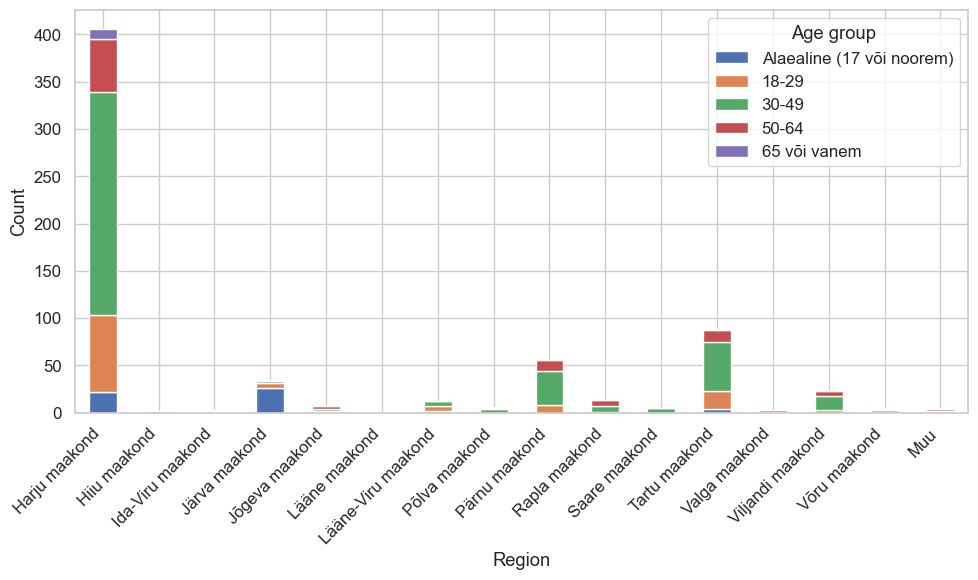

In [251]:
vanus_elukoht.plot(kind="bar", stacked=True, figsize=(10,6))

plt.ylabel("Count")
plt.xlabel("Region")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Age group")

plt.tight_layout()
plt.show()

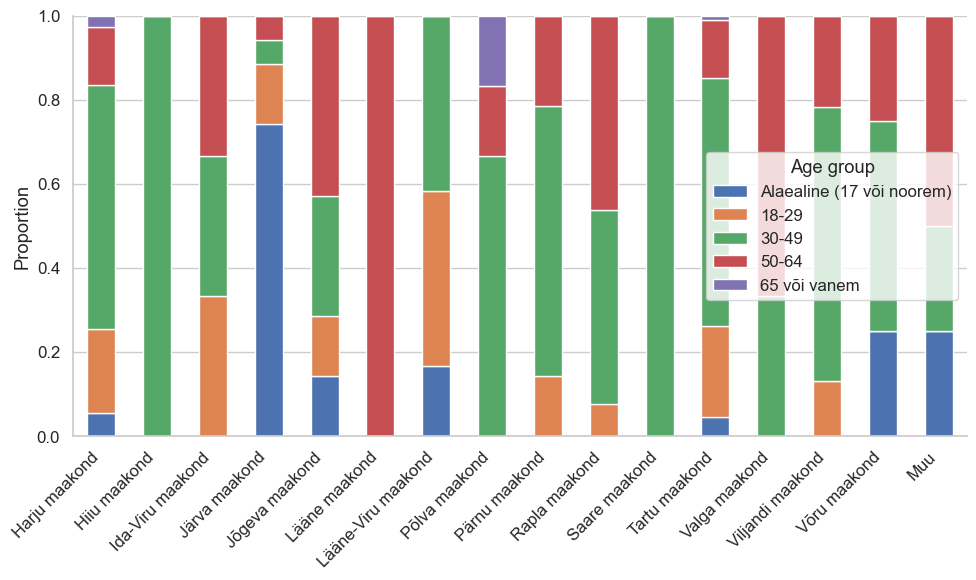

In [296]:
df_pct = vanus_elukoht.div(vanus_elukoht.sum(axis=1), axis=0)

df_pct.plot(kind="bar", stacked=True, figsize=(10,6))

plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Age group")

plt.tight_layout()
plt.show()

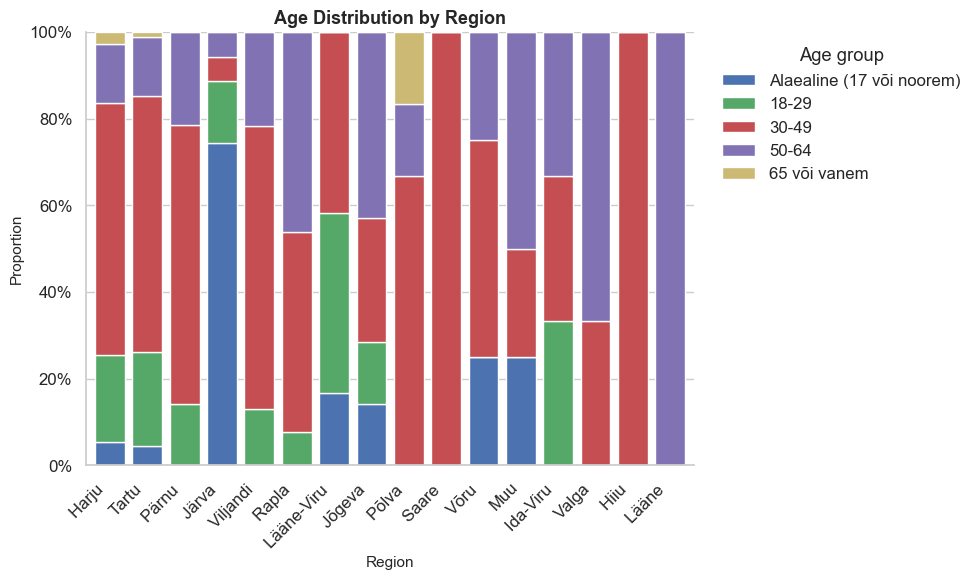

In [255]:

# --- Normalize to percentages ---
df_pct = vanus_elukoht.div(vanus_elukoht.sum(axis=1), axis=0)

# --- Sort regions by total size (optional but recommended) ---
df_pct = df_pct.loc[vanus_elukoht.sum(axis=1).sort_values(ascending=False).index]

df_pct.index = df_pct.index.str.replace("maakond", "", regex=False)

# --- Define a clean, thesis-friendly color palette ---
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

df_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.8
)

# --- Labels ---
ax.set_ylabel("Proportion", fontsize=11)
ax.set_xlabel("Region", fontsize=11)
ax.set_title("Age Distribution by Region", fontsize=13, weight="bold")

# --- Format y-axis as % ---
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

# --- Clean up axes ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Rotate x labels for readability ---
plt.xticks(rotation=45, ha="right")

# --- Legend styling ---
ax.legend(
    title="Age group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# --- Layout ---
plt.tight_layout()

plt.show()

In [233]:
vanus_keel = pd.crosstab(index=data['K3_vanus'], columns=data['K6_keel'])

vanus_keel.columns = ['Eesti keel', 'Inglise keel', 'Vene keel', 'Muu']
vanus_keel.index= ['Alaealine (17 või noorem)', '18-29', '30-49', '50-64', '65 või vanem']

vanus_keel

,Eesti keel,Inglise keel,Vene keel,Muu
Alaealine (17 või noorem),51,0,3,3
18-29,116,2,5,1
30-49,359,4,6,1
50-64,103,1,0,0
65 või vanem,12,0,1,0


In [238]:
sugu_elukoht = pd.crosstab(index=data['K5_elukoht'], columns=data['K4_sugu'], margins=True, margins_name='Kokku')
sugu_elukoht.columns = ['Mees', 'Naine', 'Ei soovi määratleda', 'Kokku']
sugu_elukoht.index = [
    'Harju maakond',
    'Hiiu maakond',
    'Ida-Viru maakond',
    'Järva maakond',
    'Jõgeva maakond',
    'Lääne maakond',
    'Lääne-Viru maakond',
    'Põlva maakond',
    'Pärnu maakond',
    'Rapla maakond',
    'Saare maakond',
    'Tartu maakond',
    'Valga maakond',
    'Viljandi maakond',
    'Võru maakond',
    'Muu',
    'Kokku'
]

sugu_elukoht

,Mees,Naine,Ei soovi määratleda,Kokku
Harju maakond,40,363,3,406
Hiiu maakond,0,2,0,2
Ida-Viru maakond,0,3,0,3
Järva maakond,17,17,1,35
Jõgeva maakond,1,6,0,7
Lääne maakond,0,1,0,1
Lääne-Viru maakond,1,11,0,12
Põlva maakond,1,5,0,6
Pärnu maakond,8,48,0,56
Rapla maakond,0,13,0,13


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume you have two DataFrames:
# df_data: contains your survey responses (numerical codes)
# df_labels: contains the mapping (kysimus, kood, vastus)



# METHOD 2: Map all variables at once (more efficient)
# -----------------------------------------------------
def create_labeled_dataset(df_data, df_labels):
    """Replace all codes with labels in the entire dataset"""
    
    df_labeled = df_data.copy()
    
    for var in df_labels['kysimus'].unique():
        if var in df_labeled.columns:
            # Create mapping dictionary
            mapping = df_labels[df_labels['kysimus'] == var].set_index('kood')['vastus'].to_dict()
            # Replace codes with labels
            df_labeled[var] = df_labeled[var].map(mapping)
    
    return df_labeled

df_labeled = create_labeled_dataset(df_data, df_labels)

# Now plot is simple:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_labeled, x='K3_vanus', order=df_labeled['K3_vanus'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.show()


# METHOD 3: Function for multiple subplots
# -----------------------------------------
def plot_multiple_variables(df_data, df_labels, variables, ncols=2):
    """Create subplot grid for multiple variables"""
    
    nrows = (len(variables) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
    axes = axes.flatten() if len(variables) > 1 else [axes]
    
    for idx, var in enumerate(variables):
        # Get labels
        labels_map = df_labels[df_labels['kysimus'] == var].set_index('kood')['vastus'].to_dict()
        
        # Count and map
        counts = df_data[var].value_counts().sort_index()
        plot_df = pd.DataFrame({
            'label': [labels_map.get(k, str(k)) for k in counts.index],
            'count': counts.values
        })
        
        # Plot
        sns.barplot(data=plot_df, x='label', y='count', ax=axes[idx])
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
        axes[idx].set_title(var)
        axes[idx].set_xlabel('')
    
    # Hide empty subplots
    for idx in range(len(variables), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Example:
plot_multiple_variables(df_data, df_labels, ['K3_vanus', 'K4_sugu', 'K2_kontroll'])


# METHOD 4: Horizontal bars for long labels
# ------------------------------------------
def plot_horizontal(df_data, df_labels, variable_name):
    """Use horizontal bars when labels are long"""
    
    labels_map = df_labels[df_labels['kysimus'] == variable_name].set_index('kood')['vastus'].to_dict()
    
    counts = df_data[variable_name].value_counts().sort_index()
    plot_df = pd.DataFrame({
        'label': [labels_map.get(k, str(k)) for k in counts.index],
        'count': counts.values
    })
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_df, y='label', x='count', orient='h')
    plt.title(f'{variable_name}')
    plt.tight_layout()
    plt.show()

plot_horizontal(df_data, df_labels, 'K3_vanus')

NameError: name 'df_data' is not defined

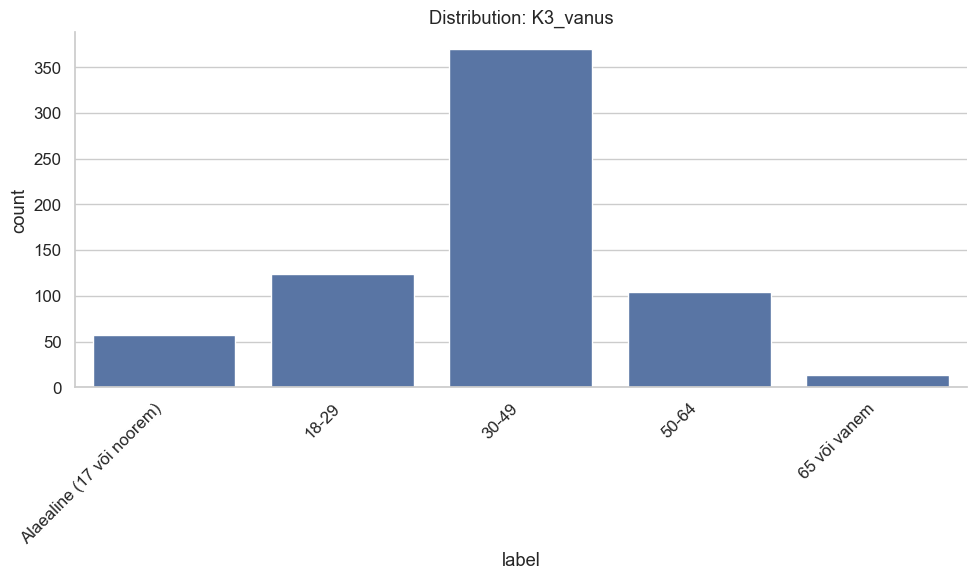

In [305]:
"""
Example: Creating barplots when data and labels are in separate tables
Specifically for FRE_andmestik.xlsx structure
"""
  
# ============================================================================
# STEP 1: Load your data
# ============================================================================
 
# Load data dictionary (labels table)
df_labels = pd.read_csv('data/vastuste_koodid.csv')
 
# Load actual survey data (assuming it's in Sheet1 or another file)
# data_df = pd.read_excel('your_survey_data.xlsx', sheet_name='Sheet1')
 
# For demonstration, creating sample data:
df_data = pd.DataFrame({
    'Vastaja_ID': range(1, 101),
    'K3_vanus': [2, 3, 2, 4, 3, 2, 3, 4, 5, 2] * 10,  # Age groups
    'K4_sugu': [1, 2, 1, 2, 3, 1, 2, 1, 2, 1] * 10,   # Gender
})
 
# METHOD 1: Map labels for a single variable
# ----------------------------------------------
def plot_single_variable(df_data, df_labels, variable_name):
    """Plot frequency distribution with proper labels"""
    
    # Get label mapping for this variable
    labels_map = df_labels[df_labels['kysimus'] == variable_name].set_index('kood')['vastus'].to_dict()
    
    # Count frequencies
    counts = df_data[variable_name].value_counts().sort_index()
    
    # Create DataFrame with labels
    plot_df = pd.DataFrame({
        'code': counts.index,
        'count': counts.values
    })
    plot_df['label'] = plot_df['code'].map(labels_map)
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_df, x='label', y='count')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribution: {variable_name}')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_single_variable(data, koodid, 'K3_vanus')



In [330]:
# METHOD 2: Map all variables at once (more efficient)
# -----------------------------------------------------
def create_labeled_dataset(df_data, df_labels):
    """Replace all codes with labels in the entire dataset"""
    
    data_labeled = data[['K2_kontroll','K3_vanus']].copy()
    
    for var in df_labels['kysimus'].unique():
        if var in df_labeled.columns:
            # Create mapping dictionary
            mapping = df_labels[df_labels['kysimus'] == var].set_index('kood')['vastus'].to_dict()
            # Replace codes with labels
            data_labeled[var] = data_labeled[var].map(mapping)
    
    return data_labeled



df_labeled = create_labeled_dataset(data, df_labels)

print(df_labeled)

# Now plot is simple:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_labeled, x='K3_vanus', order=df_labeled['K3_vanus'].value_counts().index, hue='K4_sugu')
plt.xticks(rotation=45, ha='right')
plt.show()


KeyError: 'K4_sugu'

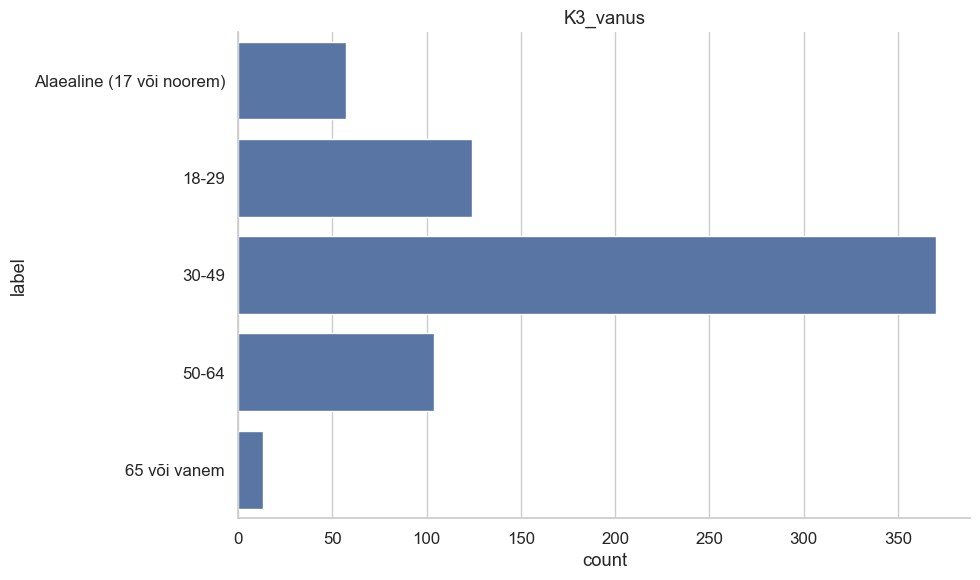

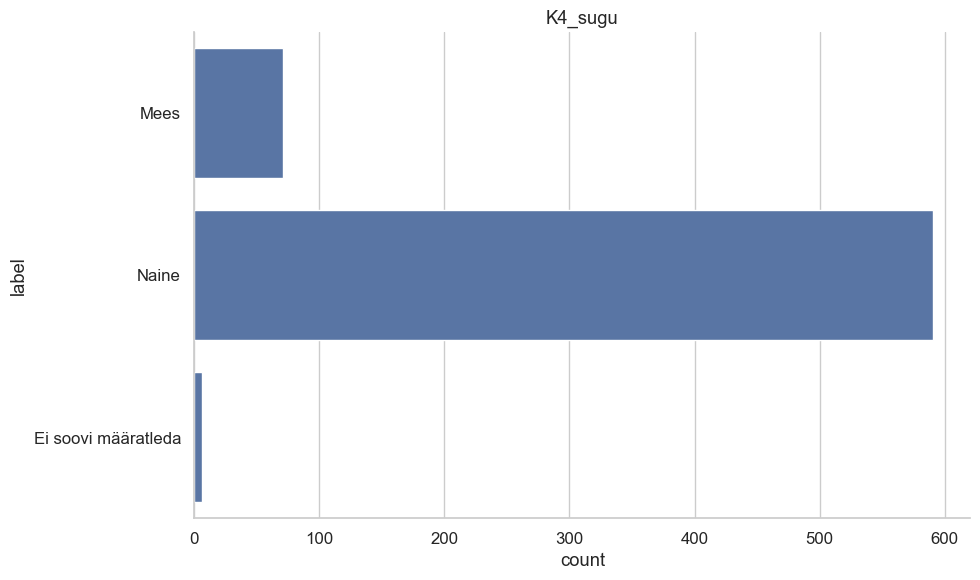

In [ ]:


# METHOD 4: Horizontal bars for long labels
# ------------------------------------------
def plot_horizontal(df_data, df_labels, tunnus):
    """Use horizontal bars when labels are long"""
    
    labels_map = leia_sildi_mapping(df_labels, tunnus)
    
    counts = df_data[tunnus].value_counts().sort_index()
    plot_df = pd.DataFrame({
        'label': [labels_map.get(k, str(k)) for k in counts.index],
        'count': counts.values
    })
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_df, y='label', x='count', orient='h')
    plt.title(f'{tunnus}')
    plt.tight_layout()
    plt.show()

plot_horizontal(data, df_labels, 'K3_vanus')
plot_horizontal(data, df_labels, 'K4_sugu')

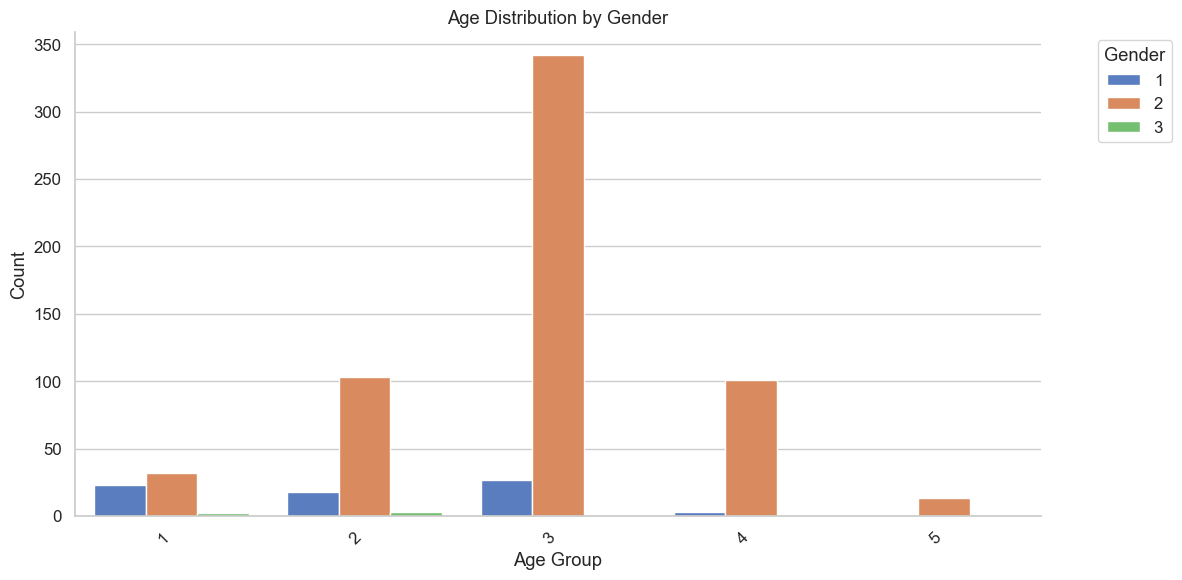

In [331]:
# ============================================================================
# METHOD 3: GROUPED BARPLOT (Comparing across categories)
# ============================================================================
 
# Create grouped data
grouped_data = data.groupby(['K3_vanus', 'K4_sugu']).size().reset_index(name='count')
 
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_data, x='K3_vanus', y='count', hue='K4_sugu', palette='muted')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Distribution by Gender')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('age_by_gender.png', dpi=300, bbox_inches='tight')
#plt.close()
plt.show()

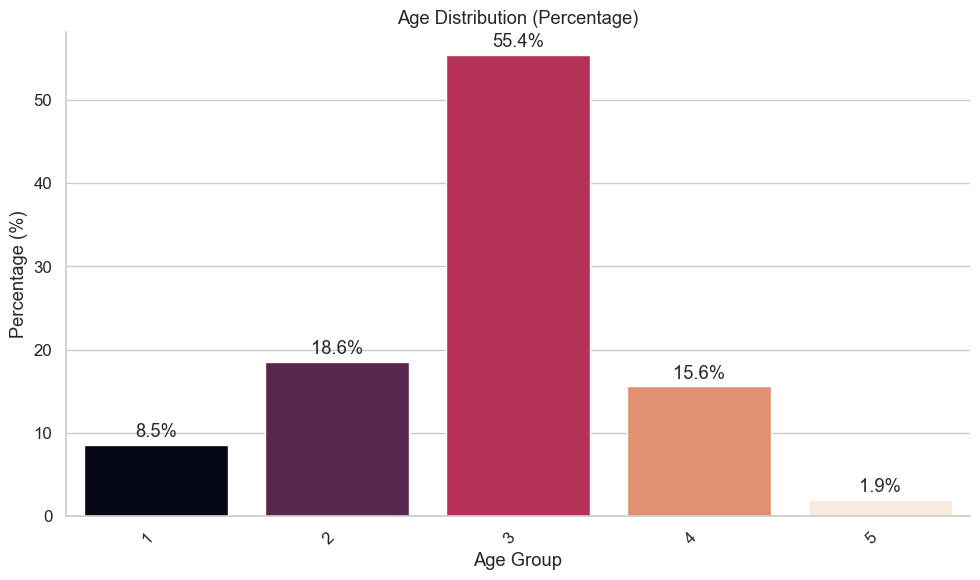


✅ All plots created successfully!

Key takeaways:
1. Use .map() to apply code-to-label mappings
2. Define manual mappings when parsing codebook is difficult
3. Specify order explicitly for ordinal variables
4. Use horizontal plots for long labels
5. Consider percentages for better comparison across groups


In [ ]:

# ============================================================================
# METHOD 5: PERCENTAGE BARPLOT
# ============================================================================
 
plt.figure(figsize=(10, 6))
counts = data['K3_vanus'].value_counts()
percentages = (counts / counts.sum() * 100).sort_index()
 
sns.barplot(x=percentages.index, y=percentages.values, hue=percentages.index, palette='rocket', legend=False)
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.title('Age Distribution (Percentage)')
plt.xticks(rotation=45, ha='right')
 
# Add percentage labels on bars
for i, (idx, val) in enumerate(percentages.items()):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom')
 
plt.tight_layout()
plt.show()

# Salvesta graafik faili
# plt.savefig('age_percentage.png', dpi=300, bbox_inches='tight')
# plt.close()
 
print("\n✅ All plots created successfully!")
print("\nKey takeaways:")
print("1. Use .map() to apply code-to-label mappings")
print("2. Define manual mappings when parsing codebook is difficult")
print("3. Specify order explicitly for ordinal variables")
print("4. Use horizontal plots for long labels")
print("5. Consider percentages for better comparison across groups")

## Descriptive Statistics for This Survey Dataset

Based on the data dictionary analysis, this is a **textile waste and consumer behavior survey** with 105 variables. Here are the appropriate descriptive statistics by variable type:

### **1. Demographic Variables (Categorical - Nominal/Ordinal)**

**Variables:** K3_vanus (age), K4_sugu (gender), K5_elukoht (location), K6_keel (language)

**Recommended statistics:**
- **Frequency distributions** - count and percentage for each category
- **Mode** - most common category
- **Cross-tabulations** - relationships between demographics
- **Bar charts/pie charts** for visualization

**Reasoning:** Nominal variables lack numerical meaning, so only frequency-based measures apply.

---

### **2. Likert Scale Variables (Ordinal - 1-5 scales)**

**Variables:** K8_teadmiste_hinnang, K9_probleemi_tosidus, K17_valmisolek_parandamiseks, K21_loobumise_lihtsus, K37_rahulolu_garderoobiga, K41_ultrakiirmoe_ostmine, K43_roivaste_tellimine_proovimiseks (7 total)

**Recommended statistics:**
- **Median** - central tendency (more appropriate than mean for ordinal data)
- **Mode** - most frequent response
- **Interquartile range (IQR)** - spread of middle 50%
- **Frequency distribution** - % at each scale point
- **Mean** (with caveat) - acceptable if treating as interval data
- **Standard deviation** (with caveat) - if treating as interval
- **Stacked bar charts** or **diverging stacked bar charts** for visualization

**Reasoning:** Likert scales are technically ordinal, but often analyzed as interval data. Median is statistically safer, but mean is commonly used for practical interpretation.

---

### **3. Multiple Choice Questions (Binary/Boolean)**

**Variable groups:** 
- K15_mittevajalikud_tekstiilid (7 options)
- K19_loobumise_pohjused (9 options) 
- K22_peamised_valjakutsed (7 options)
- K23_kasutuskolbmatud_tekstiilid (7 options)
- K25_loobumisel_oluline (7 options)
- K32_teabe_allikad (10 options)
- K33_julgustavad_tegurid (7 options)

**Recommended statistics:**
- **Selection frequency** - % who selected each option
- **Response rate** - % who answered the question
- **Total selections per respondent** (mean, median) - shows if people select 1 vs many
- **Co-occurrence matrix** - which options are selected together
- **Ranked order** by frequency

**Reasoning:** Each option is independent; statistics should show popularity and patterns of selection.

---

### **4. Single-Choice Categorical Variables (Nominal)**

**Variables:** K7_sorteerimiskaitumine, K26_korduskasutuseks_sobimatud_tekstiilid, K28_riikliku_juhise_selgus, K29_sobiv_kogumisviis, K30_valmisolek_kategoriseerimiseks, K38_kandmise_kestus, K40_ostmissagedus

**Recommended statistics:**
- **Frequency table** - count and percentage
- **Mode** - most common choice
- **Diversity index** (optional) - how evenly distributed responses are
- **Chi-square tests** for associations with demographics

**Reasoning:** These are mutually exclusive categories without inherent order.

---

### **5. Open-Ended Text Variables**

**Variables:** K5_elukoht_muu_tekst, K6_keel_muu_tekst, K10_probleemi_tosidus_tapsustus, etc. (28 total)

**Recommended statistics:**
- **Response rate** - % who provided text
- **Word count** statistics (mean, median, range)
- **Thematic coding** - categorize into themes, then frequency analysis
- **Word frequency analysis** or **word clouds**
- **Sentiment analysis** (if applicable)

**Reasoning:** Qualitative data requires coding before quantitative analysis.

---

### **6. Metadata Variables**

**Variables:** Vastaja_ID (respondent ID), K1_aeg (timestamp)

**Recommended statistics:**
- **Total respondents** (unique IDs)
- **Survey completion rate**
- **Time-based analysis:** responses by date, time of day, duration patterns
- **Duplicate detection**

---

### **Summary Statistics Report Structure**

A complete analysis should include:

1. **Sample characteristics** (n, completion rate, demographics)
2. **Central tendency measures** (mean/median by variable type)
3. **Dispersion measures** (SD, IQR, range)
4. **Distribution analysis** (frequency tables, histograms)
5. **Bivariate analysis** (correlations, cross-tabs by demographics)
6. **Missing data analysis** (% missing by variable)
7. **Reliability checks** (for multi-item scales, calculate Cronbach's alpha if applicable)

This structure respects the measurement level of each variable type while providing actionable insights for textile waste management policy decisions.

In [ ]:
# Guard: preview may be shorter if history is limited
print(f"Daily temperature preview window: {start_d.date()} … {end_d.date()} (rows: {len(last_nd)}, target: {N_DAYS})")
if last_nd.empty:
    raise RuntimeError("Empty preview window. Widen MONTHS or check the available date range.")

# 4) Preview table
display(last_nd)

# 5) Plot: last N days (line). For bars: use kind="bar".
ax = (last_nd.set_index("avg_day_temp_date")["hour_day_value"]
               .plot(kind="line",
                     figsize=(10, 3),
                     title=f"Daily average temperature — last {N_DAYS} days — {TZ}",
                     rot=45))
ax.set_xlabel("Date (local)")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 6) Data types & quick info
print("=== DAILY TEMP (FULL DATASET): shape ===", df_daily_t.shape)
print("=== DAILY TEMP (FULL DATASET): date range ===",
      df_daily_t["avg_day_temp_date"].min(), "→", df_daily_t["avg_day_temp_date"].max())
print("\n=== DAILY TEMP (FULL DATASET): dtypes ===")
print(df_daily_t.dtypes)
print("\n=== DAILY TEMP (FULL DATASET): .info() ===")
df_daily_t.info()